In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#📌 Extracción

In [2]:
datos = pd.read_json('/content/TelecomX_Data.json')
datos.head(10)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
5,0013-MHZWF,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
6,0013-SMEOE,No,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Two year', 'PaperlessBilling': '..."
7,0014-BMAQU,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Two year', 'PaperlessBilling': '..."
8,0015-UOCOJ,No,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
9,0016-QLJIS,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [5]:
datos.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

#🔧 Transformación

In [6]:
datos.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [8]:
datos['customerID'].duplicated().sum()

np.int64(0)

#📊 Carga y análisis

In [9]:
customer = pd.json_normalize(datos['customer'])
phone = pd.json_normalize(datos['phone'])
internet = pd.json_normalize(datos['internet'])
account = pd.json_normalize(datos['account'])

In [10]:
datos_limpios = pd.concat(
    [datos[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

datos_limpios.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [11]:
datos_limpios.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [12]:
datos_limpios["Charges.Total"] = pd.to_numeric(
    datos_limpios["Charges.Total"], errors="coerce"
)

In [13]:
datos_limpios["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [14]:
datos_limpios.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [15]:
datos_limpios["Cuentas_Diarias"] = datos_limpios["Charges.Monthly"] / 30

In [16]:
datos_limpios[["Charges.Monthly", "Cuentas_Diarias"]].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [17]:
columnas_binarias = [
    "Partner","Dependents","PhoneService","PaperlessBilling",
    "OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies"
]

for col in columnas_binarias:
    datos_limpios[col] = datos_limpios[col].map({"Yes":1, "No":0})

In [18]:
datos_limpios["Churn"] = datos_limpios["Churn"].map({"Yes":1, "No":0})

In [19]:
datos_limpios = datos_limpios.rename(columns={
    "Charges.Monthly": "Cargos_Mensuales",
    "Charges.Total": "Cargos_Totales",
    "tenure": "Antiguedad_Cliente"
})

In [20]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7267 non-null   object 
 1   Churn               7043 non-null   float64
 2   gender              7267 non-null   object 
 3   SeniorCitizen       7267 non-null   int64  
 4   Partner             7267 non-null   int64  
 5   Dependents          7267 non-null   int64  
 6   Antiguedad_Cliente  7267 non-null   int64  
 7   PhoneService        7267 non-null   int64  
 8   MultipleLines       7267 non-null   object 
 9   InternetService     7267 non-null   object 
 10  OnlineSecurity      5686 non-null   float64
 11  OnlineBackup        5686 non-null   float64
 12  DeviceProtection    5686 non-null   float64
 13  TechSupport         5686 non-null   float64
 14  StreamingTV         5686 non-null   float64
 15  StreamingMovies     5686 non-null   float64
 16  Contra

In [21]:
datos_limpios.describe()

,Churn,SeniorCitizen,Partner,Dependents,Antiguedad_Cliente,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,5686.000000,5686.000000,5686.000000,5686.000000,5686.000000,5686.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.265370,0.162653,0.484106,0.300124,32.346498,0.902711,0.365459,0.440380,0.438094,0.370032,0.490679,0.495251,0.593230,64.720098,2280.634213,2.157337
std,0.441561,0.369074,0.499782,0.458343,24.571773,0.296371,0.481601,0.496476,0.496196,0.482855,0.499957,0.500021,0.491265,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,400.225000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [23]:
datos_limpios["Antiguedad_Cliente"].describe()

,Antiguedad_Cliente
count,7267.000000
mean,32.346498
std,24.571773
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [24]:
datos_limpios.describe()

,Churn,SeniorCitizen,Partner,Dependents,Antiguedad_Cliente,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,5686.000000,5686.000000,5686.000000,5686.000000,5686.000000,5686.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.265370,0.162653,0.484106,0.300124,32.346498,0.902711,0.365459,0.440380,0.438094,0.370032,0.490679,0.495251,0.593230,64.720098,2280.634213,2.157337
std,0.441561,0.369074,0.499782,0.458343,24.571773,0.296371,0.481601,0.496476,0.496196,0.482855,0.499957,0.500021,0.491265,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,400.225000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


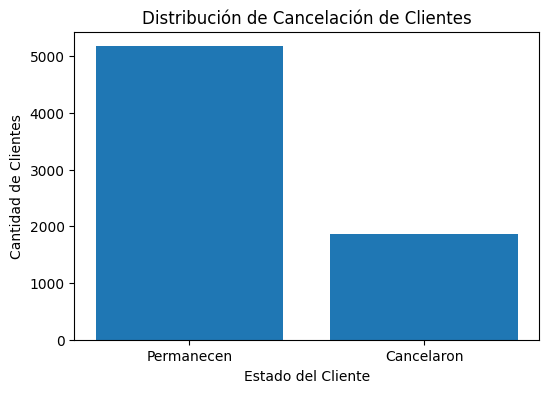

In [25]:
churn_counts = datos_limpios["Churn"].dropna().value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Permanecen","Cancelaron"], churn_counts)

plt.title("Distribución de Cancelación de Clientes")
plt.xlabel("Estado del Cliente")
plt.ylabel("Cantidad de Clientes")

plt.show()

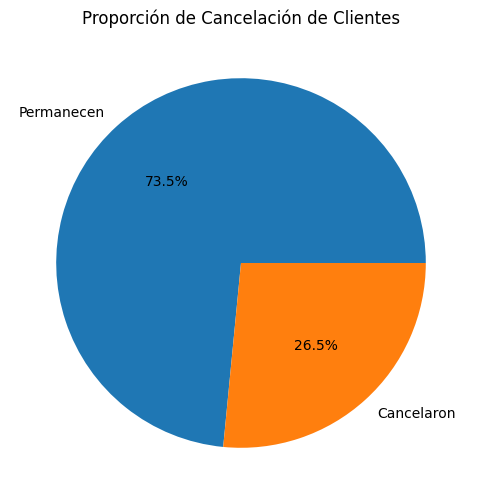

In [26]:
churn_counts = datos_limpios["Churn"].dropna().value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=["Permanecen","Cancelaron"], autopct="%1.1f%%")

plt.title("Proporción de Cancelación de Clientes")

plt.show()

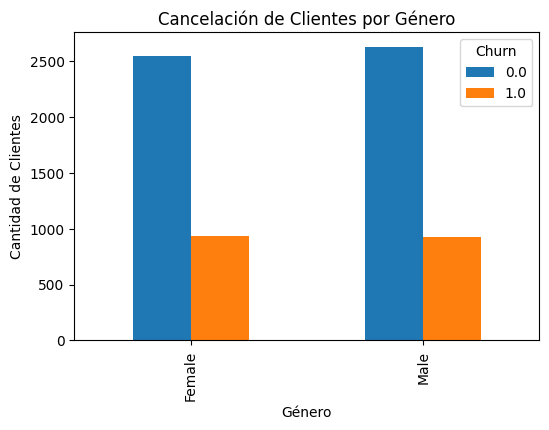

In [27]:
tabla_genero = pd.crosstab(datos_limpios["gender"], datos_limpios["Churn"])

tabla_genero.plot(kind="bar", figsize=(6,4))

plt.title("Cancelación de Clientes por Género")
plt.xlabel("Género")
plt.ylabel("Cantidad de Clientes")

plt.show()

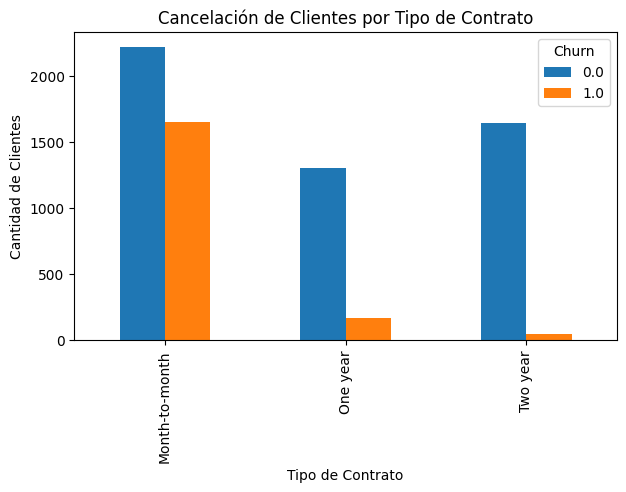

In [28]:
tabla_contrato = pd.crosstab(datos_limpios["Contract"], datos_limpios["Churn"])

tabla_contrato.plot(kind="bar", figsize=(7,4))

plt.title("Cancelación de Clientes por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Cantidad de Clientes")

plt.show()

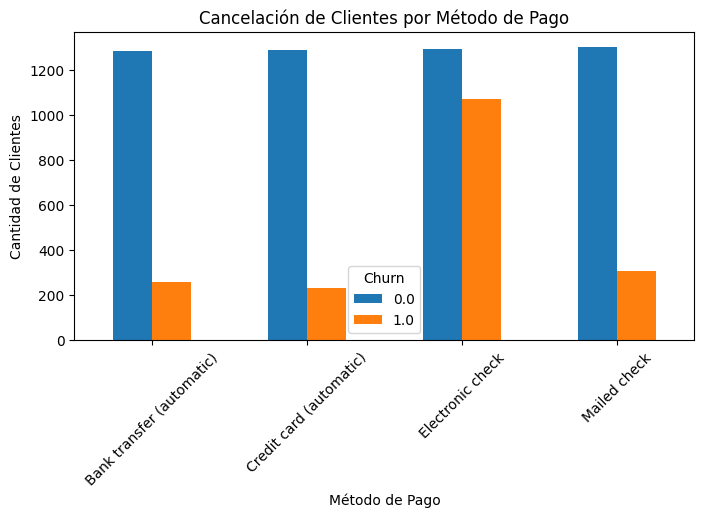

In [29]:
tabla_pago = pd.crosstab(datos_limpios["PaymentMethod"], datos_limpios["Churn"])

tabla_pago.plot(kind="bar", figsize=(8,4))

plt.title("Cancelación de Clientes por Método de Pago")
plt.xlabel("Método de Pago")
plt.ylabel("Cantidad de Clientes")

plt.xticks(rotation=45)

plt.show()

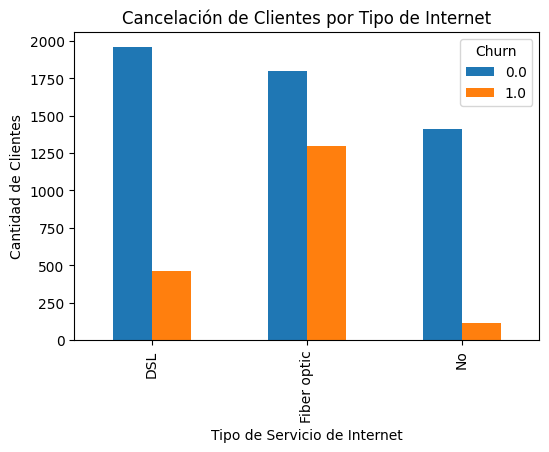

In [30]:
tabla_internet = pd.crosstab(datos_limpios["InternetService"], datos_limpios["Churn"])

tabla_internet.plot(kind="bar", figsize=(6,4))

plt.title("Cancelación de Clientes por Tipo de Internet")
plt.xlabel("Tipo de Servicio de Internet")
plt.ylabel("Cantidad de Clientes")

plt.show()

<Figure size 600x400 with 0 Axes>

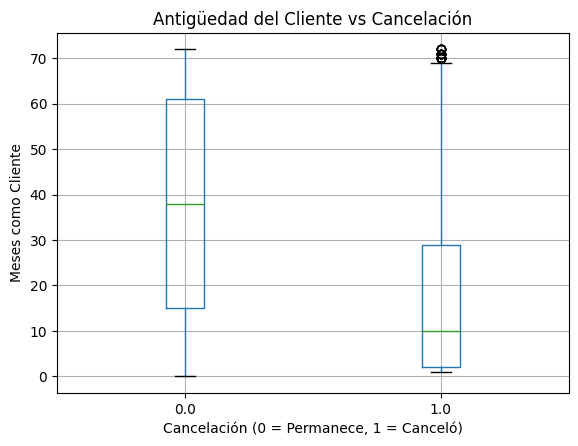

In [31]:
plt.figure(figsize=(6,4))

datos_limpios.boxplot(column="Antiguedad_Cliente", by="Churn")

plt.title("Antigüedad del Cliente vs Cancelación")
plt.suptitle("")
plt.xlabel("Cancelación (0 = Permanece, 1 = Canceló)")
plt.ylabel("Meses como Cliente")

plt.show()

<Figure size 600x400 with 0 Axes>

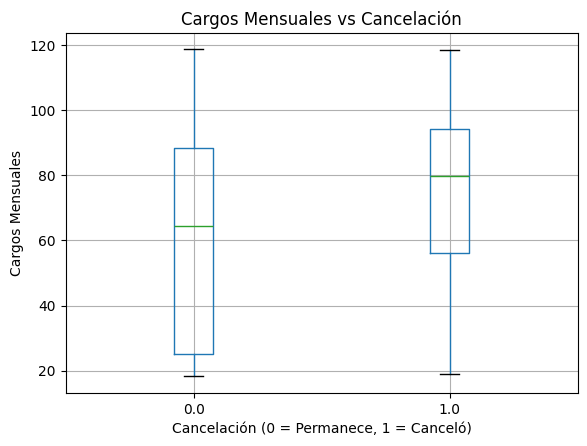

In [32]:
plt.figure(figsize=(6,4))

datos_limpios.boxplot(column="Cargos_Mensuales", by="Churn")

plt.title("Cargos Mensuales vs Cancelación")
plt.suptitle("")
plt.xlabel("Cancelación (0 = Permanece, 1 = Canceló)")
plt.ylabel("Cargos Mensuales")

plt.show()

<Figure size 600x400 with 0 Axes>

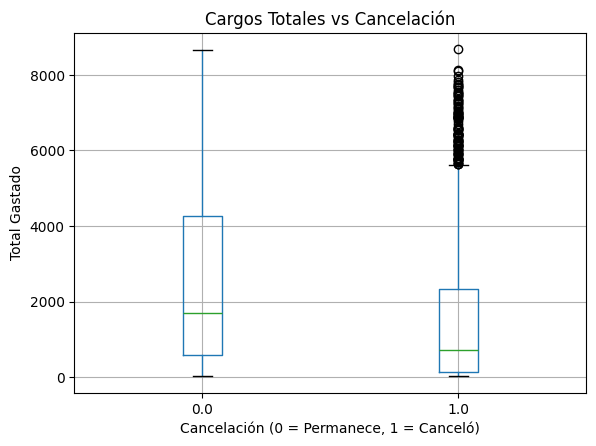

In [34]:
plt.figure(figsize=(6,4))

datos_limpios.boxplot(column="Cargos_Totales", by="Churn")

plt.title("Cargos Totales vs Cancelación")
plt.suptitle("")
plt.xlabel("Cancelación (0 = Permanece, 1 = Canceló)")
plt.ylabel("Total Gastado")

plt.show()

<Figure size 600x400 with 0 Axes>

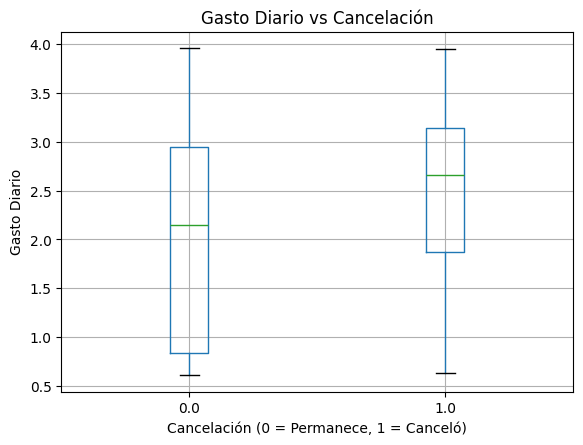

In [35]:
plt.figure(figsize=(6,4))

datos_limpios.boxplot(column="Cuentas_Diarias", by="Churn")

plt.title("Gasto Diario vs Cancelación")
plt.suptitle("")
plt.xlabel("Cancelación (0 = Permanece, 1 = Canceló)")
plt.ylabel("Gasto Diario")

plt.show()

#📄Informe final